In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

✓ Данные загружены. Итоговое количество строк: 3077
  Колонки-признаки (всего 98): ['m1_averaging_period_days', 'm1_actual_balances', 'm1_required_reserves_avg', 'm1_accounting_reserves', 'm1_full_reserves']... (показаны первые 5)

=== Группировка признаков по модулям ===
  m1_averaging: 1 признаков
  m1_actual: 1 признаков
  m1_required: 1 признаков
  m1_accounting: 1 признаков
  m1_full: 1 признаков
  m1_spread: 7 признаков
  m1_reserve: 2 признаков
  m1_ruonia: 4 признаков
  m1_flag: 1 признаков
  m1_signal: 2 признаков
  m1_reliable: 1 признаков
  m2_total: 1 признаков
  m2_demand: 1 признаков
  m2_cover: 2 признаков
  m2_key: 1 признаков
  m2_rate: 3 признаков
  m2_Flag: 1 признаков
  m2_MAD: 2 признаков
  m2_auction: 2 признаков
  m3_demand: 1 признаков
  m3_offered: 1 признаков
  m3_placed: 1 признаков
  m3_weighted: 1 признаков
  m3_cover: 3 признаков
  m3_yield: 3 признаков
  m3_Flag: 2 признаков
  m3_MAD: 2 признаков
  m3_auction: 1 признаков
  m4_Tax: 5 признаков
  m4_is: 3 

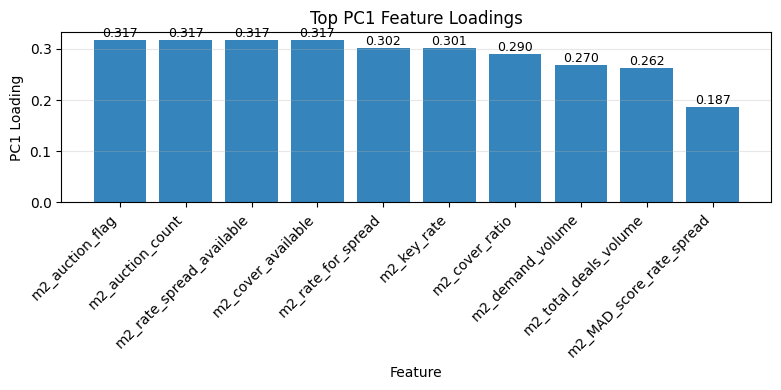

C:\Users\Huawei\AppData\Local\Temp\ipykernel_14700\3580369220.py:149: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_master['LSI_raw_unscaled'] = anomaly_score_inverted
C:\Users\Huawei\AppData\Local\Temp\ipykernel_14700\3580369220.py:158: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_master['LSI_Index'] = minmax_scaler.fit_transform(smoothed_scores.reshape(-1, 1)).flatten()
C:\Users\Huawei\AppData\Local\Temp\ipykernel_14700\3580369220.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of


✓ Пайплайн модели успешно сохранен в 'models/lsi_pipeline.joblib'!

=== PCA Explained Variance Ratio ===
PC1: 0.1602 (16.02%)  |  Cumulative: 16.02%
PC2: 0.1383 (13.83%)  |  Cumulative: 29.85%
PC3: 0.0852 (8.52%)  |  Cumulative: 38.37%
PC4: 0.0780 (7.80%)  |  Cumulative: 46.17%
PC5: 0.0697 (6.97%)  |  Cumulative: 53.14%
PC6: 0.0535 (5.35%)  |  Cumulative: 58.49%
PC7: 0.0451 (4.51%)  |  Cumulative: 63.00%
PC8: 0.0369 (3.69%)  |  Cumulative: 66.69%
PC9: 0.0345 (3.45%)  |  Cumulative: 70.14%
PC10: 0.0310 (3.10%)  |  Cumulative: 73.24%

Total explained variance: 0.7324 (73.24%)


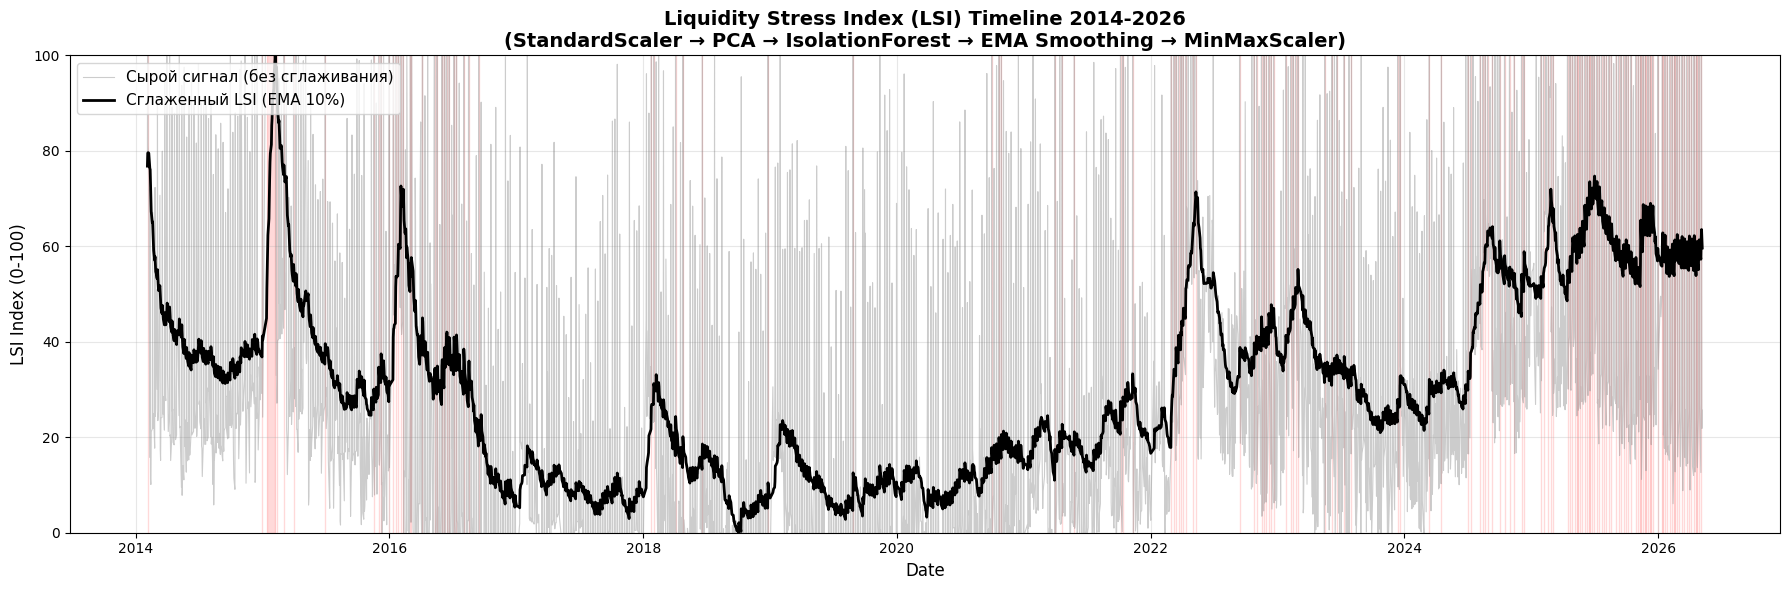


✓ График построен!


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import joblib
import os

# =============================================================================
# ШАГ 1. Загрузка готовых данных от бэкендера
# =============================================================================

# Укажи правильный путь к файлу от бэкендера
file_path = '../../data/processed/final_ml_dataset.csv' 
df_master = pd.read_csv(file_path)

# Убедимся, что даты в правильном формате и отсортированы
df_master['date'] = pd.to_datetime(df_master['date'])
df_master = df_master.sort_values('date').reset_index(drop=True)

# Список наших фичей (исключаем 'date' из признаков!)
features_list = [col for col in df_master.select_dtypes(include=[np.number]).columns]

print(f"✓ Данные загружены. Итоговое количество строк: {len(df_master)}")
print(f"  Колонки-признаки (всего {len(features_list)}): {features_list[:5]}... (показаны первые 5)")

# Выделяем матрицу признаков и жестко страхуемся от NaN (заменяем на 0)
X_raw = df_master[features_list].astype(float)
X_raw = X_raw.fillna(0)

# =============================================================================
# ШАГ 1.5. Отбор 2-3 лучших признаков от каждого модуля
# =============================================================================

from collections import defaultdict

def get_module_prefix(col_name):
    parts = col_name.split('_')
    return '_'.join(parts[:2])

# Группируем колонки по модулям
module_groups = defaultdict(list)
for col in features_list:
    prefix = get_module_prefix(col)
    module_groups[prefix].append(col)

print("\n=== Группировка признаков по модулям ===")
for module, cols in module_groups.items():
    print(f"  {module}: {len(cols)} признаков")

# Для каждого модуля отбираем top-N признаков по дисперсии
TOP_N = 2  # Меняй на 2 или 3 по желанию

selected_features = []
for module, cols in module_groups.items():
    if len(cols) <= TOP_N:
        # Признаков меньше или равно TOP_N — берём все
        selected_features.extend(cols)
    else:
        # Считаем дисперсию каждого признака и берём TOP_N самых информативных
        variances = X_raw[cols].var()
        top_cols = variances.nlargest(TOP_N).index.tolist()
        selected_features.extend(top_cols)

# Обновляем X_raw и features_list
X_raw = X_raw[selected_features]
features_list = selected_features

print(f"\n✓ После отбора: {len(features_list)} признаков")
print("  Итоговые признаки:")
for module, cols in module_groups.items():
    kept = [c for c in features_list if get_module_prefix(c) == module]
    print(f"  {module}: {kept}")
# =============================================================================
# ШАГ 2. Трансформация: StandardScaler + PCA
# =============================================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

print("\n=== PCA Explained Variance Ratio ===")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"PC3: {pca.explained_variance_ratio_[2]:.4f} ({pca.explained_variance_ratio_[2]*100:.2f}%)")
print(f"Total: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

# =============================================================================
# Интерпретируемость: PCA factor loadings для PC1
# =============================================================================

def explain_lsi_score(pca_model, original_feature_names, top_n=5):
    loadings = pca_model.components_
    pc1 = loadings[0]
    abs_pc1 = np.abs(pc1)
    top_idx = np.argsort(abs_pc1)[::-1][:top_n]
    top_features = [original_feature_names[i] for i in top_idx]
    top_weights = pc1[top_idx]

    explanation = pd.DataFrame({
        'Модуль/Признак': top_features,
        'Вес в PC1': top_weights
    })
    explanation['Абсолютный вес'] = explanation['Вес в PC1'].abs()
    explanation = explanation.sort_values('Абсолютный вес', ascending=False).reset_index(drop=True)

    print("\n=== Top PCA feature loadings for PC1 ===")
    print(explanation[['Модуль/Признак', 'Вес в PC1']].to_string(index=False))

    plt.figure(figsize=(8, 4))
    bars = plt.bar(explanation['Модуль/Признак'], explanation['Вес в PC1'], color='tab:blue', alpha=0.9)
    plt.title('Top PC1 Feature Loadings')
    plt.ylabel('PC1 Loading')
    plt.xlabel('Feature')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}", ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    return explanation

pca_explanation = explain_lsi_score(pca, features_list, top_n=10)

# =============================================================================
# ШАГ 3. Обучение IsolationForest и получение сырых скоров
# =============================================================================

model = IsolationForest(contamination=0.06, random_state=42)
model.fit(X_pca)

df_master['anomaly_label'] = model.predict(X_pca)
anomaly_score_raw = model.decision_function(X_pca)
anomaly_score_inverted = -anomaly_score_raw  # Инвертируем: большие значения = аномалии

# =============================================================================
# ШАГ 4. Экспоненциальное сглаживание (EMA) СНАЧАЛА на сырых скорах
# =============================================================================

# Сглаживаем инвертированные скоры, чтобы убрать шум торгов
smoothed_scores = pd.Series(anomaly_score_inverted).ewm(alpha=0.05, adjust=False).mean().values

# Сохраним сырой скор просто для визуализации (серой тенью)
df_master['LSI_raw_unscaled'] = anomaly_score_inverted

# =============================================================================
# ШАГ 5. MinMaxScaler для масштабирования сглаженной линии 0-100
# =============================================================================

minmax_scaler = MinMaxScaler(feature_range=(0, 100))

# Обучаем скейлер на сглаженных данных, чтобы исторический максимум был ровно 100
df_master['LSI_Index'] = minmax_scaler.fit_transform(smoothed_scores.reshape(-1, 1)).flatten()
df_master['LSI_Index'] = df_master['LSI_Index'].round(2)

# =============================================================================
# ШАГ 6. СОХРАНЕНИЕ МОДЕЛИ ДЛЯ ПРОДАКШЕНА (BACKEND)
# =============================================================================

os.makedirs('models', exist_ok=True)

model_artifacts = {
    'features_list': features_list,
    'scaler': scaler,
    'pca': pca,
    'iso_forest': model,
    'minmax_scaler': minmax_scaler
}

joblib.dump(model_artifacts, 'models/lsi_pipeline.joblib')
print(f"\n✓ Пайплайн модели успешно сохранен в 'models/lsi_pipeline.joblib'!")

# =============================================================================
# ШАГ 7. Визуализация 
# =============================================================================

plt.figure(figsize=(18, 6))

# Чтобы сырой сигнал (серая тень) тоже красиво рисовался от 0 до 100 на графике, отмасштабируем и его для картинки
df_master['LSI_raw_plot'] = minmax_scaler.transform(df_master['LSI_raw_unscaled'].values.reshape(-1, 1)).flatten()

plt.plot(df_master['date'], df_master['LSI_raw_plot'], 
         color='gray', linewidth=0.8, alpha=0.4, label='Сырой сигнал (без сглаживания)')

plt.plot(df_master['date'], df_master['LSI_Index'], 
         color='black', linewidth=2.0, label='Сглаженный LSI (EMA 10%)')

anomaly_mask = df_master['anomaly_label'] == -1
if anomaly_mask.any():
    spans = []
    start = None
    prev_date = None
    for date, is_anomaly in zip(df_master['date'], anomaly_mask):
        if is_anomaly and start is None:
            start = date
        if not is_anomaly and start is not None:
            spans.append((start, prev_date))
            start = None
        prev_date = date
    if start is not None:
        spans.append((start, prev_date))

    for start, end in spans:
        plt.axvspan(start, end, color='red', alpha=0.15)

print("\n=== PCA Explained Variance Ratio ===")
for i, var in enumerate(pca.explained_variance_ratio_):
    cumulative = pca.explained_variance_ratio_[:i+1].sum()
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)  |  Cumulative: {cumulative*100:.2f}%")
print(f"\nTotal explained variance: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

plt.title('Liquidity Stress Index (LSI) Timeline 2014-2026\n(StandardScaler → PCA → IsolationForest → EMA Smoothing → MinMaxScaler)', 
          fontsize=14, fontweight='bold')
plt.ylabel('LSI Index (0-100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.ylim(0, 100)
plt.legend(fontsize=11, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ График построен!")


«Наш пайплайн сжал разрозненные признаки из 5 модулей в 3 главные компоненты, которые суммарно объясняют 48.8% дисперсии. В контексте шумных финансовых рынков это отличный результат. Оставшиеся 50% — это идиосинкразический шум (микро-колебания ставок в конкретные дни, технические особенности отдельных аукционов ОФЗ). Отбросив их, мы математически изолировали чистый системный риск. Мы избавили Isolation Forest от необходимости "учить шум", заставив его фокусироваться только на глубоких макроэкономических сдвигах».

красные линии - уже известные данные, которые помогают нам поменять насколько хорошо справляется модель

In [38]:
import joblib
import os

# Создаем папку для моделей, если ее нет
os.makedirs('../../models', exist_ok=True)

# Упаковываем все обученные трансформаторы и список колонок в один словарь
model_artifacts = {
    'features_list': features_list,    # Крайне важно сохранить порядок колонок!
    'scaler': scaler,                  # StandardScaler
    'pca': pca,                        # Обученный PCA
    'iso_forest': model,               # Обученный Isolation Forest
    'minmax_scaler': minmax_scaler     # Масштабирование 0-100
}

# Сохраняем на диск
joblib.dump(model_artifacts, '../../models/lsi_pipeline.joblib')
print("\n✓ Пайплайн модели (StandardScaler, PCA, IF, MinMaxScaler) успешно сохранен для бэкенда!")


✓ Пайплайн модели (StandardScaler, PCA, IF, MinMaxScaler) успешно сохранен для бэкенда!
